# Jacobian quality analysis

This notebook is a path-driven diagnostic for an MMC/mmcnirs Jacobian archive. It is intentionally independent of the simulator pipeline so it can move upstream into **mmcnirs**, where these failures should be detected.

Change `JACOBIAN_PATH` below and run all cells. Companion `probe.npz` and `mesh.npz` files are discovered beside the Jacobian when available. The notebook does not modify any input files.

## What this notebook checks

The plots are designed to make spatially structured failures obvious, rather than reducing the file to one pass/fail number.

- **Archive structure:** required keys, exact source/detector/node dimensions, numeric arrays, and valid unique `channelidx` rows.
- **Forward measurements:** finite and strictly positive `mea0` for selected channels. A zero selected baseline is fatal because projected intensity becomes constant after clipping.
- **Transport fields:** finite, nonzero source/detector Green fields; finite positive `Green_sd`; finite nonzero Jacobian rows.
- **Cross-field consistency:** a positive Jacobian or normalizer paired with zero direct detected-photon weight is highlighted as a pipeline inconsistency.
- **Probe agreement:** registered positions and the selected source-detector set must agree with the companion probe archive. Stored short/long channel IDs are preferred over a distance heuristic.
- **Geometry (when mesh is available):** signed optode depth is compared with the detector capture radius. A detector center deeper than its radius is a strong warning sign.

Fatal findings fail the quality gate. Review findings do not, but should be understood before using the archive.

In [2]:
from html import escape
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

plt.rcParams.update(
    {
        "figure.dpi": 115,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
    }
)

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find a project root containing pyproject.toml")

PROJECT_ROOT = find_project_root(Path.cwd())

# Main input: change this path to inspect another wavelength or hardware folder.
JACOBIAN_PATH = PROJECT_ROOT / "workflow_example/e2e-files" / "mmcnirs_outputs" / "jacobian_690.npz"

# Optional companion inputs. Set either to None to skip its checks.
PROBE_PATH = JACOBIAN_PATH.with_name("probe.npz")
MESH_PATH = JACOBIAN_PATH.with_name("mesh.npz")

# Normally inferred from detpos[:, 3]. Set explicitly if the archive lacks that column.
DETECTOR_RADIUS_MM = None

# Exact probe/Jacobian reproducibility should normally differ only by floating-point noise.
PROBE_POSITION_ATOL_MM = 1e-6

# Used only when probe short/long IDs are unavailable.
FALLBACK_SHORT_DISTANCE_MM = 20.0

print(f"Jacobian: {JACOBIAN_PATH}")
print(f"Probe:    {PROBE_PATH if PROBE_PATH and PROBE_PATH.exists() else 'not available'}")
print(f"Mesh:     {MESH_PATH if MESH_PATH and MESH_PATH.exists() else 'not available'}")

Jacobian: /Users/nielsbracher/Projects/mmc-nirs/workflow_example/e2e-files/mmcnirs_outputs/jacobian_690.npz
Probe:    /Users/nielsbracher/Projects/mmc-nirs/workflow_example/e2e-files/mmcnirs_outputs/probe.npz
Mesh:     /Users/nielsbracher/Projects/mmc-nirs/workflow_example/e2e-files/mmcnirs_outputs/mesh.npz


In [3]:
def load_npz(path: Path) -> dict[str, np.ndarray]:
    if not path.is_file():
        raise FileNotFoundError(path)
    with np.load(path, allow_pickle=False) as archive:
        return {key: archive[key] for key in archive.files}

def human_bytes(size: int) -> str:
    value = float(size)
    for unit in ("B", "KiB", "MiB", "GiB"):
        if value < 1024 or unit == "GiB":
            return f"{value:.1f} {unit}"
        value /= 1024
    raise AssertionError("unreachable")

jac = load_npz(JACOBIAN_PATH)
memory_bytes = sum(array.nbytes for array in jac.values())

print(f"Loaded {len(jac)} arrays ({human_bytes(memory_bytes)} in memory)")
print(f"{'key':<12} {'shape':<18} {'dtype':<12} {'size'}")
for key, array in jac.items():
    print(f"{key:<12} {str(array.shape):<18} {str(array.dtype):<12} {human_bytes(array.nbytes)}")

Loaded 10 arrays (228.8 MiB in memory)
key          shape              dtype        size
Green_d      (31, 58686)        float64      13.9 MiB
Green_s      (15, 58686)        float64      6.7 MiB
Green_sd     (465, 1)           float64      3.6 KiB
J            (465, 58686)       float64      208.2 MiB
channelidx   (51,)              int64        408.0 B
mea0         (465, 1)           float64      3.6 KiB
sourcepos    (15, 3)            float64      360.0 B
detpos       (31, 4)            float64      992.0 B
detnorms     (31, 3)            float64      744.0 B
sourcedir    (15, 3)            float64      360.0 B


In [18]:
REQUIRED_KEYS = {
    "Green_d",
    "Green_s",
    "Green_sd",
    "J",
    "channelidx",
    "mea0",
    "sourcepos",
    "detpos",
    "detnorms",
    "sourcedir",
}

quality_findings: list[dict[str, object]] = []

def add_finding(check: str, bad_count: int, detail: str, failure_level: str = "FATAL") -> None:
    quality_findings.append(
        {
            "status": "PASS" if bad_count == 0 else failure_level,
            "check": check,
            "count": int(bad_count),
            "detail": detail,
        }
    )

missing = sorted(REQUIRED_KEYS - jac.keys())
if missing:
    add_finding("Required archive keys", len(missing), f"Missing: {', '.join(missing)}")
    raise KeyError(f"Missing required Jacobian arrays: {missing}")
add_finding("Required archive keys", 0, "All expected arrays are present")

source_positions = np.asarray(jac["sourcepos"], dtype=float)
detector_positions_with_radius = np.asarray(jac["detpos"], dtype=float)
if source_positions.ndim != 2 or source_positions.shape[1] != 3:
    raise ValueError(f"sourcepos must have shape (n_sources, 3), got {source_positions.shape}")
if (
    detector_positions_with_radius.ndim != 2
    or detector_positions_with_radius.shape[1] not in (3, 4)
):
    raise ValueError(
        "detpos must have shape (n_detectors, 3) or (n_detectors, 4), "
        f"got {detector_positions_with_radius.shape}"
    )

source_count = len(source_positions)
detector_count = len(detector_positions_with_radius)
detector_positions = detector_positions_with_radius[:, :3]
row_count = source_count * detector_count

green_source = np.asarray(jac["Green_s"], dtype=float)
green_detector = np.asarray(jac["Green_d"], dtype=float)
if green_source.ndim != 2:
    raise ValueError(f"Green_s must be 2D, got {green_source.shape}")
node_count = green_source.shape[1]

expected_shapes = {
    "Green_s": (source_count, node_count),
    "Green_d": (detector_count, node_count),
    "Green_sd": (row_count, 1),
    "J": (row_count, node_count),
    "mea0": (row_count, 1),
    "sourcedir": (source_count, 3),
    "detnorms": (detector_count, 3),
}
shape_errors = [
    f"{key}: expected {expected}, got {np.asarray(jac[key]).shape}"
    for key, expected in expected_shapes.items()
    if np.asarray(jac[key]).shape != expected
]
add_finding(
    "Array dimensions",
    len(shape_errors),
    "All arrays follow the source-major Jacobian schema"
    if not shape_errors
    else "; ".join(shape_errors),
)
if shape_errors:
    raise ValueError("Jacobian schema errors:\n" + "\n".join(shape_errors))

raw_channel_indices = np.asarray(jac["channelidx"]).reshape(-1)
indices_are_integral = (
    np.issubdtype(raw_channel_indices.dtype, np.integer)
    or (
        np.issubdtype(raw_channel_indices.dtype, np.number)
        and np.all(np.isfinite(raw_channel_indices))
        and np.all(raw_channel_indices == np.floor(raw_channel_indices))
    )
)
if not indices_are_integral:
    raise ValueError("channelidx must contain finite integer row indices")
selected_rows = raw_channel_indices.astype(np.intp, copy=False)
out_of_range = (selected_rows < 0) | (selected_rows >= row_count)
add_finding(
    "channelidx range",
    np.count_nonzero(out_of_range),
    f"Valid zero-based range is [0, {row_count - 1}]",
)
if np.any(out_of_range):
    raise ValueError("channelidx contains out-of-range rows")
duplicate_count = len(selected_rows) - len(np.unique(selected_rows))
add_finding("Unique selected rows", duplicate_count, f"{len(selected_rows)} selected channels")

selected_mask_flat = np.zeros(row_count, dtype=bool)
selected_mask_flat[selected_rows] = True
selected_mask = selected_mask_flat.reshape(source_count, detector_count)

green_normalizer = np.asarray(jac["Green_sd"], dtype=float).reshape(-1)
baseline = np.asarray(jac["mea0"], dtype=float).reshape(-1)
jacobian = np.asarray(jac["J"], dtype=float)

source_green_norm = np.linalg.norm(green_source, axis=1)
detector_green_norm = np.linalg.norm(green_detector, axis=1)
jacobian_row_norm = np.linalg.norm(jacobian, axis=1)

baseline_matrix = baseline.reshape(source_count, detector_count)
normalizer_matrix = green_normalizer.reshape(source_count, detector_count)
jacobian_norm_matrix = jacobian_row_norm.reshape(source_count, detector_count)
source_detector_distances = np.linalg.norm(
    source_positions[:, None, :] - detector_positions[None, :, :],
    axis=2,
)

selected_bad_baseline = selected_mask_flat & (~np.isfinite(baseline) | (baseline <= 0))
unselected_bad_baseline = ~selected_mask_flat & (~np.isfinite(baseline) | (baseline <= 0))
unselected_zero_baseline = (
    ~selected_mask_flat
    & np.isfinite(baseline)
    & (baseline == 0)
)
unselected_invalid_baseline = (
    ~selected_mask_flat
    & (~np.isfinite(baseline) | (baseline < 0))
)

invalid_normalizer = ~np.isfinite(green_normalizer) | (green_normalizer < 0)
selected_bad_normalizer = selected_mask_flat & (
    ~np.isfinite(green_normalizer) | (green_normalizer <= 0)
)
invalid_jacobian_row = ~np.isfinite(jacobian_row_norm)
selected_bad_jacobian_row = selected_mask_flat & (
    ~np.isfinite(jacobian_row_norm) | (jacobian_row_norm <= 0)
)

baseline_zero = baseline == 0
normalizer_zero = green_normalizer == 0

zero_pattern_mismatch = baseline_zero != normalizer_zero

zero_measurement_nonzero_jacobian = (
    (green_normalizer == 0)
    & np.isfinite(jacobian_row_norm)
    & (jacobian_row_norm > 0)
)

add_finding(
    "Zero-reflectance/J consistency",
    np.count_nonzero(zero_measurement_nonzero_jacobian),
    "Rows with zero reflectance must have zero sensitivity",
)

add_finding(
    "mea0/Green_sd zero-pattern consistency",
    np.count_nonzero(zero_pattern_mismatch),
    "mea0 and Green_sd derive from the same detected-photon weights and must vanish together",
)
add_finding(
    "Selected mea0 is finite and positive",
    np.count_nonzero(selected_bad_baseline),
    "Non-positive selected baselines cannot produce meaningful intensity changes",
)
add_finding(
    "Unselected mea0 is finite and positive",
    np.count_nonzero(unselected_bad_baseline),
    "Unselected rows are retained in the archive and reveal detector-wide failures",
    failure_level="REVIEW",
)
add_finding(
    "Unselected mea0 is finite and non-negative",
    np.count_nonzero(unselected_invalid_baseline),
    "Unselected source-detector pairs may legitimately have zero detected weight",
)

add_finding(
    "Unselected zero-photon pairs",
    np.count_nonzero(unselected_zero_baseline),
    "Zero baselines are allowed for source-detector pairs outside the measurement montage",
    failure_level="REVIEW",
)
add_finding(
    "Green_sd is finite and non-negative",
    np.count_nonzero(invalid_normalizer),
    "Zero reflectance is allowed for unmeasured source-detector pairs",
)

add_finding(
    "Selected Green_sd is finite and positive",
    np.count_nonzero(selected_bad_normalizer),
    "Every selected measurement channel requires positive baseline reflectance",
)
add_finding(
    "Source Green fields are finite and nonzero",
    np.count_nonzero(~np.isfinite(source_green_norm) | (source_green_norm <= 0)),
    f"Checked {source_count} source fields",
)
add_finding(
    "Detector Green fields are finite and nonzero",
    np.count_nonzero(~np.isfinite(detector_green_norm) | (detector_green_norm <= 0)),
    f"Checked {detector_count} adjoint detector fields",
)
add_finding(
    "Jacobian rows are finite",
    np.count_nonzero(invalid_jacobian_row),
    f"Checked {row_count} source-detector rows",
)

add_finding(
    "Selected Jacobian rows are nonzero",
    np.count_nonzero(selected_bad_jacobian_row),
    f"Checked {len(selected_rows)} selected source-detector rows",
)

positive_measurement = np.isfinite(baseline_matrix) & (baseline_matrix > 0)
detector_coverage = positive_measurement.sum(axis=0)
source_coverage = positive_measurement.sum(axis=1)
zero_coverage_detectors = detector_coverage == 0
zero_coverage_sources = source_coverage == 0
add_finding(
    "Direct detector coverage",
    np.count_nonzero(zero_coverage_detectors),
    f"Expected positive measurements from up to {source_count} sources per detector",
    failure_level="REVIEW",
)
add_finding(
    "Direct source coverage",
    np.count_nonzero(zero_coverage_sources),
    f"Expected positive measurements at up to {detector_count} detectors per source",
    failure_level="REVIEW",
)

print(
    f"Schema: {source_count} sources × {detector_count} detectors = {row_count} rows; "
    f"{node_count:,} mesh nodes; {len(selected_rows)} selected channels"
)

Schema: 15 sources × 31 detectors = 465 rows; 58,686 mesh nodes; 51 selected channels


In [19]:
probe = None
mesh = None
probe_pair_rows = None
source_position_delta = None
detector_position_delta = None
short_pair_rows = np.array([], dtype=np.intp)
long_pair_rows = np.array([], dtype=np.intp)

if PROBE_PATH is not None and PROBE_PATH.is_file():
    probe = load_npz(PROBE_PATH)
    required_probe_keys = {
        "sourcepos",
        "detpos",
        "channel_pairings",
        "short_separation_indices",
        "long_separation_indices",
    }
    missing_probe = sorted(required_probe_keys - probe.keys())
    add_finding(
        "Companion probe fields",
        len(missing_probe),
        "All selection and short/long metadata are available"
        if not missing_probe
        else f"Missing: {', '.join(missing_probe)}",
    )
    if not missing_probe:
        probe_sources = np.asarray(probe["sourcepos"], dtype=float)
        probe_detectors = np.asarray(probe["detpos"], dtype=float)[:, :3]
        position_shapes_match = (
            probe_sources.shape == source_positions.shape
            and probe_detectors.shape == detector_positions.shape
        )
        if position_shapes_match:
            source_position_delta = np.linalg.norm(
                probe_sources - source_positions,
                axis=1,
            )
            detector_position_delta = np.linalg.norm(
                probe_detectors - detector_positions,
                axis=1,
            )
            all_position_delta = np.concatenate(
                (source_position_delta, detector_position_delta)
            )
            mismatched_position_count = np.count_nonzero(
                all_position_delta > PROBE_POSITION_ATOL_MM
            )
            maximum_position_delta = np.max(all_position_delta, initial=0.0)
        else:
            mismatched_position_count = source_count + detector_count
            maximum_position_delta = np.inf
        add_finding(
            "Jacobian/probe registered positions",
            mismatched_position_count,
            (
                f"Maximum Euclidean difference: {maximum_position_delta:.3g} mm; "
                f"tolerance: {PROBE_POSITION_ATOL_MM:g} mm"
            ),
        )

        pairings = np.asarray(probe["channel_pairings"])
        pairing_valid = (
            pairings.ndim == 2
            and pairings.shape[1] == 2
            and np.issubdtype(pairings.dtype, np.integer)
            and len(np.unique(pairings, axis=0)) == len(pairings)
            and np.all(pairings[:, 0] >= 0)
            and np.all(pairings[:, 0] < source_count)
            and np.all(pairings[:, 1] >= 0)
            and np.all(pairings[:, 1] < detector_count)
        )
        add_finding(
            "Probe channel pairings",
            int(not pairing_valid),
            "Pairings must be unique, zero-based (source, detector) indices",
        )
        if pairing_valid:
            probe_pair_rows = (
                pairings[:, 0].astype(np.intp) * detector_count
                + pairings[:, 1].astype(np.intp)
            )
            selection_mismatch = np.setxor1d(probe_pair_rows, selected_rows)
            add_finding(
                "channelidx/probe selected set",
                len(selection_mismatch),
                "Both files must select the same source-detector rows",
            )

            short_indices = np.asarray(probe["short_separation_indices"], dtype=np.intp).reshape(-1)
            long_indices = np.asarray(probe["long_separation_indices"], dtype=np.intp).reshape(-1)
            metadata_indices = np.concatenate((short_indices, long_indices))
            metadata_invalid = (
                np.any(metadata_indices < 0)
                or np.any(metadata_indices >= len(pairings))
                or len(np.intersect1d(short_indices, long_indices)) > 0
                or len(np.union1d(short_indices, long_indices)) != len(pairings)
            )
            add_finding(
                "Stored short/long channel partition",
                int(metadata_invalid),
                "Probe channel IDs must be disjoint and cover every pairing",
            )
            if not metadata_invalid:
                short_pair_rows = probe_pair_rows[short_indices]
                long_pair_rows = probe_pair_rows[long_indices]
else:
    add_finding(
        "Companion probe archive",
        1,
        "Probe-specific selection and channel-class checks were skipped",
        failure_level="REVIEW",
    )

selected_is_short = np.isin(selected_rows, short_pair_rows)
selected_is_long = np.isin(selected_rows, long_pair_rows)
if probe_pair_rows is None or (len(short_pair_rows) + len(long_pair_rows) == 0):
    selected_is_short = (
        source_detector_distances.reshape(-1)[selected_rows]
        <= FALLBACK_SHORT_DISTANCE_MM
    )
    selected_is_long = ~selected_is_short
    channel_class_source = f"distance ≤ {FALLBACK_SHORT_DISTANCE_MM:g} mm fallback"
else:
    channel_class_source = "stored probe IDs"

print(f"Channel classes use: {channel_class_source}")
print(f"Selected short/long: {selected_is_short.sum()}/{selected_is_long.sum()}")

Channel classes use: stored probe IDs
Selected short/long: 15/36


In [20]:
surface_distances = None
source_surface_distance = None
detector_surface_distance = None
detector_depth = None

if DETECTOR_RADIUS_MM is not None:
    detector_radius_mm = float(DETECTOR_RADIUS_MM)
elif detector_positions_with_radius.shape[1] == 4:
    radii = detector_positions_with_radius[:, 3]
    if not np.all(np.isfinite(radii)) or np.any(radii <= 0):
        detector_radius_mm = np.nan
        add_finding(
            "Detector capture radius",
            1,
            "detpos[:, 3] must contain finite positive radii",
        )
    else:
        detector_radius_mm = float(np.median(radii))
        nonuniform_radius_count = np.count_nonzero(~np.isclose(radii, detector_radius_mm))
        add_finding(
            "Detector capture radius",
            nonuniform_radius_count,
            f"Median radius: {detector_radius_mm:.3f} mm",
            failure_level="REVIEW",
        )
else:
    detector_radius_mm = np.nan
    add_finding(
        "Detector capture radius",
        1,
        "No explicit radius was configured and detpos has only three columns",
        failure_level="REVIEW",
    )

if MESH_PATH is not None and MESH_PATH.is_file():
    mesh = load_npz(MESH_PATH)
    if {"nodes", "elements"} <= mesh.keys():
        try:
            from mmcnirs.utils.probe_utils import _signed_surface_distances

            mesh_nodes = np.asarray(mesh["nodes"], dtype=float)
            mesh_elements = np.asarray(mesh["elements"], dtype=np.intp)
            surface_distances = _signed_surface_distances(
                np.vstack((source_positions, detector_positions)),
                mesh_nodes,
                mesh_elements,
            )
            source_surface_distance = surface_distances[:source_count]
            detector_surface_distance = surface_distances[source_count:]
            detector_depth = np.maximum(-detector_surface_distance, 0.0)

            if np.isfinite(detector_radius_mm):
                beyond_radius = detector_depth > detector_radius_mm + 1e-6
                add_finding(
                    "Detector depth versus capture radius",
                    np.count_nonzero(beyond_radius),
                    (
                        "Detector centers deeper than the MMC capture radius may not "
                        "intersect photons leaving the surface"
                    ),
                    failure_level="REVIEW",
                )
        except Exception as error:
            add_finding(
                "Signed surface distance",
                1,
                f"Geometry diagnostic failed: {type(error).__name__}: {error}",
                failure_level="REVIEW",
            )
    else:
        add_finding(
            "Companion mesh fields",
            1,
            "mesh.npz must contain nodes and elements",
            failure_level="REVIEW",
        )
else:
    add_finding(
        "Companion mesh archive",
        1,
        "Surface-depth checks were skipped",
        failure_level="REVIEW",
    )

print(
    "Detector radius: "
    + (f"{detector_radius_mm:.3f} mm" if np.isfinite(detector_radius_mm) else "unknown")
)
if detector_depth is not None:
    print(
        f"Detector depth below surface: {detector_depth.min():.3f}–"
        f"{detector_depth.max():.3f} mm"
    )

Detector radius: 1.000 mm
Detector depth below surface: 0.045–0.471 mm


In [21]:
status_order = {"FATAL": 0, "REVIEW": 1, "PASS": 2}
ordered_findings = sorted(
    quality_findings,
    key=lambda item: (status_order[str(item["status"])], str(item["check"])),
)

table_lines = [
    "| Status | Check | Count | Detail |",
    "|:--|:--|--:|:--|",
]
for item in ordered_findings:
    table_lines.append(
        f"| **{escape(str(item['status']))}** | "
        f"{escape(str(item['check']))} | "
        f"{item['count']} | {escape(str(item['detail']))} |"
    )

fatal_findings = [item for item in quality_findings if item["status"] == "FATAL"]
review_findings = [item for item in quality_findings if item["status"] == "REVIEW"]
quality_gate_passed = not fatal_findings

verdict = (
    "✅ **PASS** — no fatal findings"
    if quality_gate_passed
    else f"❌ **FAIL** — {len(fatal_findings)} fatal check(s)"
)
display(
    Markdown(
        f"## Quality-gate result\n\n{verdict}; "
        f"{len(review_findings)} check(s) require review.\n\n"
        + "\n".join(table_lines)
    )
)

## Quality-gate result

✅ **PASS** — no fatal findings; 2 check(s) require review.

| Status | Check | Count | Detail |
|:--|:--|--:|:--|
| **REVIEW** | Unselected mea0 is finite and positive | 27 | Unselected rows are retained in the archive and reveal detector-wide failures |
| **REVIEW** | Unselected zero-photon pairs | 27 | Zero baselines are allowed for source-detector pairs outside the measurement montage |
| **PASS** | Array dimensions | 0 | All arrays follow the source-major Jacobian schema |
| **PASS** | Companion probe fields | 0 | All selection and short/long metadata are available |
| **PASS** | Detector Green fields are finite and nonzero | 0 | Checked 31 adjoint detector fields |
| **PASS** | Detector capture radius | 0 | Median radius: 1.000 mm |
| **PASS** | Detector depth versus capture radius | 0 | Detector centers deeper than the MMC capture radius may not intersect photons leaving the surface |
| **PASS** | Direct detector coverage | 0 | Expected positive measurements from up to 15 sources per detector |
| **PASS** | Direct source coverage | 0 | Expected positive measurements at up to 31 detectors per source |
| **PASS** | Green_sd is finite and non-negative | 0 | Zero reflectance is allowed for unmeasured source-detector pairs |
| **PASS** | Jacobian rows are finite | 0 | Checked 465 source-detector rows |
| **PASS** | Jacobian/probe registered positions | 0 | Maximum Euclidean difference: 0 mm; tolerance: 1e-06 mm |
| **PASS** | Probe channel pairings | 0 | Pairings must be unique, zero-based (source, detector) indices |
| **PASS** | Required archive keys | 0 | All expected arrays are present |
| **PASS** | Selected Green_sd is finite and positive | 0 | Every selected measurement channel requires positive baseline reflectance |
| **PASS** | Selected Jacobian rows are nonzero | 0 | Checked 51 selected source-detector rows |
| **PASS** | Selected mea0 is finite and positive | 0 | Non-positive selected baselines cannot produce meaningful intensity changes |
| **PASS** | Source Green fields are finite and nonzero | 0 | Checked 15 source fields |
| **PASS** | Stored short/long channel partition | 0 | Probe channel IDs must be disjoint and cover every pairing |
| **PASS** | Unique selected rows | 0 | 51 selected channels |
| **PASS** | Unselected mea0 is finite and non-negative | 0 | Unselected source-detector pairs may legitimately have zero detected weight |
| **PASS** | Zero-reflectance/J consistency | 0 | Rows with zero reflectance must have zero sensitivity |
| **PASS** | channelidx range | 0 | Valid zero-based range is [0, 464] |
| **PASS** | channelidx/probe selected set | 0 | Both files must select the same source-detector rows |
| **PASS** | mea0/Green_sd zero-pattern consistency | 0 | mea0 and Green_sd derive from the same detected-photon weights and must vanish together |

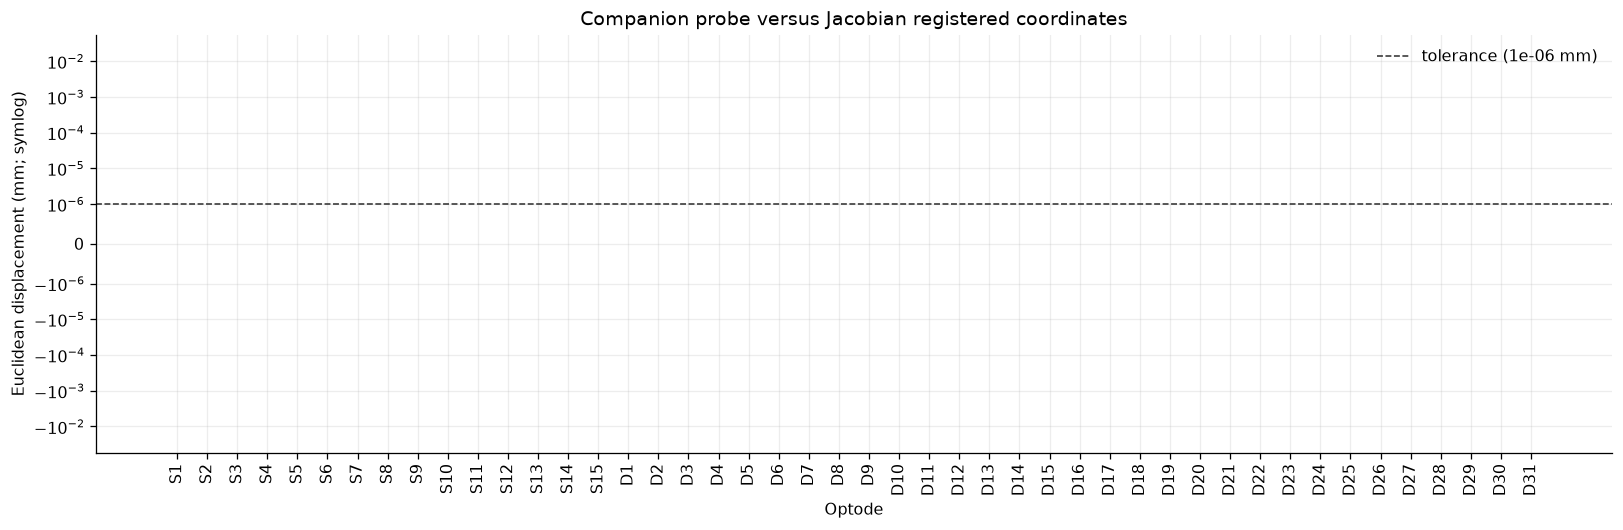

In [8]:
if source_position_delta is None or detector_position_delta is None:
    display(
        Markdown(
            "### Probe/Jacobian position comparison skipped\n\n"
            "Comparable registered coordinates were not available."
        )
    )
else:
    position_delta = np.concatenate(
        (source_position_delta, detector_position_delta)
    )
    labels = [f"S{i + 1}" for i in range(source_count)] + [
        f"D{i + 1}" for i in range(detector_count)
    ]
    mismatch = position_delta > PROBE_POSITION_ATOL_MM
    colors = np.where(mismatch, "#d62728", "#2b6cb0")

    fig, ax = plt.subplots(figsize=(14, 4.5), layout="constrained")
    ax.bar(np.arange(len(position_delta)), position_delta, color=colors)
    ax.axhline(
        PROBE_POSITION_ATOL_MM,
        color="#333333",
        linestyle="--",
        linewidth=1,
        label=f"tolerance ({PROBE_POSITION_ATOL_MM:g} mm)",
    )
    ax.set_yscale("symlog", linthresh=PROBE_POSITION_ATOL_MM)
    ax.set(
        title="Companion probe versus Jacobian registered coordinates",
        xlabel="Optode",
        ylabel="Euclidean displacement (mm; symlog)",
        xticks=np.arange(len(labels)),
        xticklabels=labels,
    )
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    plt.show()

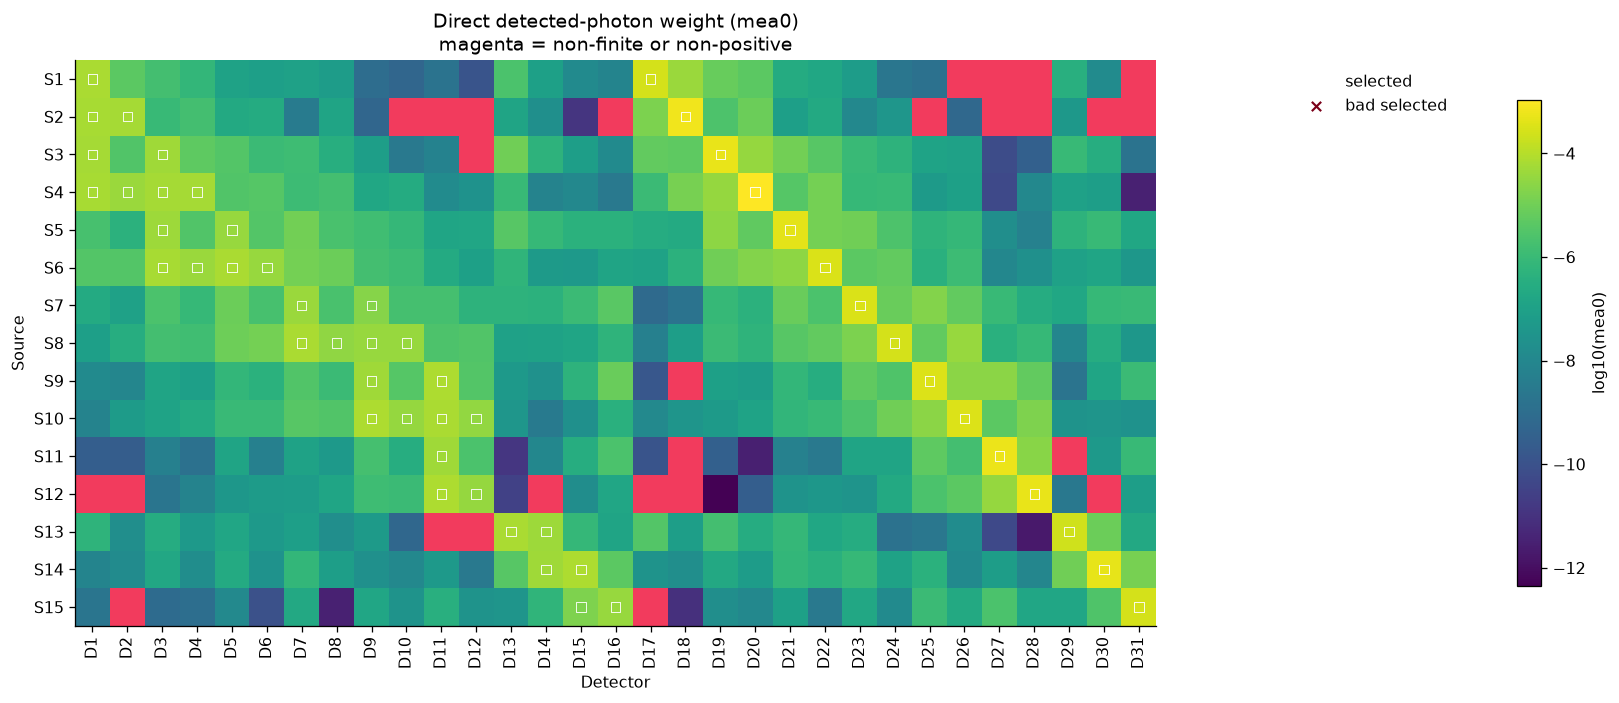

In [9]:
def channel_label(row: int) -> str:
    source_index, detector_index = divmod(int(row), detector_count)
    return f"S{source_index + 1}-D{detector_index + 1}"

def log10_or_nan(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    output = np.full(values.shape, np.nan, dtype=float)
    positive = np.isfinite(values) & (values > 0)
    output[positive] = np.log10(values[positive])
    return output

def draw_pair_heatmap(
    axis,
    values: np.ndarray,
    title: str,
    colorbar_label: str,
    bad_mask: np.ndarray | None = None,
):
    image_values = np.ma.masked_invalid(log10_or_nan(values))
    color_map = plt.colormaps["viridis"].copy()
    color_map.set_bad("#f23b5d")
    image = axis.imshow(image_values, aspect="auto", interpolation="nearest", cmap=color_map)
    selected_y, selected_x = np.where(selected_mask)
    axis.scatter(
        selected_x,
        selected_y,
        s=35,
        marker="s",
        facecolors="none",
        edgecolors="white",
        linewidths=0.55,
        label="selected",
    )
    if bad_mask is None:
        bad_mask = ~np.isfinite(values) | (values <= 0)
    bad_selected_y, bad_selected_x = np.where(selected_mask & bad_mask)
    axis.scatter(
        bad_selected_x,
        bad_selected_y,
        s=34,
        marker="x",
        color="#7a0019",
        linewidths=1.35,
        label="bad selected",
    )
    axis.set_title(title)
    axis.set_xlabel("Detector")
    axis.set_ylabel("Source")
    axis.set_xticks(np.arange(detector_count), [f"D{i + 1}" for i in range(detector_count)], rotation=90)
    axis.set_yticks(np.arange(source_count), [f"S{i + 1}" for i in range(source_count)])
    axis.grid(False)
    colorbar = axis.figure.colorbar(image, ax=axis, shrink=0.86)
    colorbar.set_label(colorbar_label)
    axis.legend(loc="upper left", bbox_to_anchor=(1.12, 1.0), frameon=False)
    return image

fig, ax = plt.subplots(figsize=(14, 6), layout="constrained")
draw_pair_heatmap(
    ax,
    baseline_matrix,
    "Direct detected-photon weight (mea0)\nmagenta = non-finite or non-positive",
    "log10(mea0)",
)
plt.show()

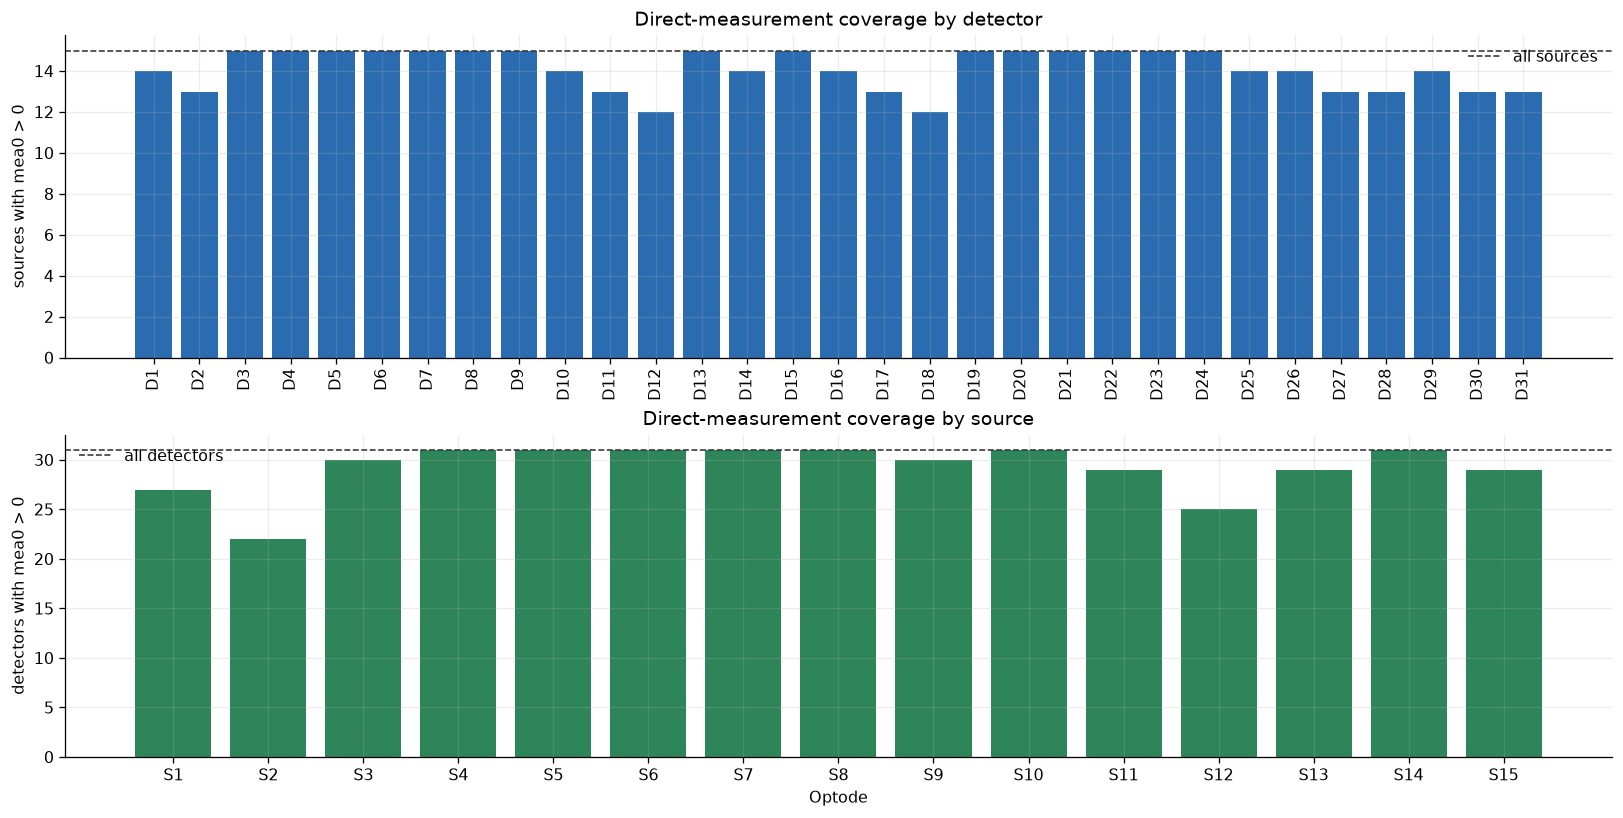

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), layout="constrained")

detector_colors = np.where(zero_coverage_detectors, "#d62728", "#2b6cb0")
axes[0].bar(np.arange(detector_count), detector_coverage, color=detector_colors)
axes[0].axhline(source_count, color="#333333", linestyle="--", linewidth=1, label="all sources")
axes[0].set(
    title="Direct-measurement coverage by detector",
    ylabel="sources with mea0 > 0",
    xticks=np.arange(detector_count),
    xticklabels=[f"D{i + 1}" for i in range(detector_count)],
)
axes[0].tick_params(axis="x", rotation=90)
axes[0].legend(frameon=False)
for index in np.flatnonzero(zero_coverage_detectors):
    axes[0].text(index, 0.25, "0", ha="center", va="bottom", color="#8b0000", fontsize=8)

source_colors = np.where(zero_coverage_sources, "#d62728", "#2f855a")
axes[1].bar(np.arange(source_count), source_coverage, color=source_colors)
axes[1].axhline(detector_count, color="#333333", linestyle="--", linewidth=1, label="all detectors")
axes[1].set(
    title="Direct-measurement coverage by source",
    ylabel="detectors with mea0 > 0",
    xlabel="Optode",
    xticks=np.arange(source_count),
    xticklabels=[f"S{i + 1}" for i in range(source_count)],
)
axes[1].legend(frameon=False)
plt.show()

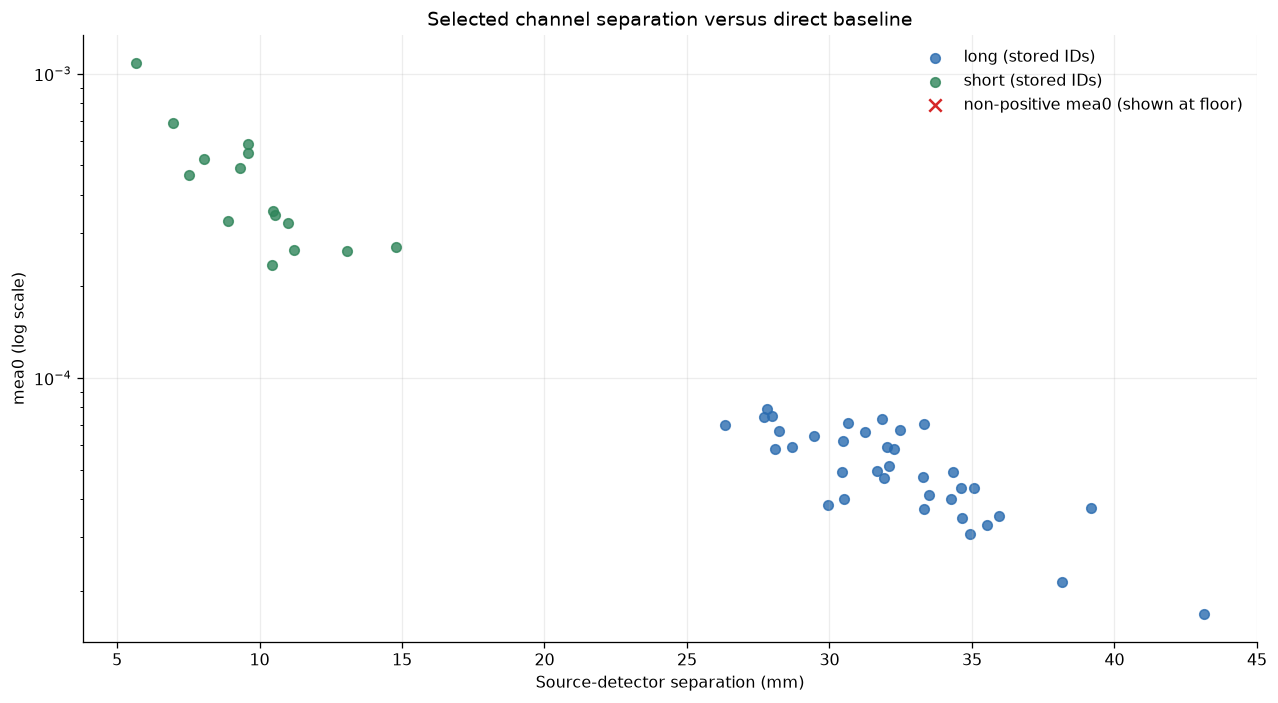

In [11]:
selected_baseline = baseline[selected_rows]
selected_distance = source_detector_distances.reshape(-1)[selected_rows]
selected_bad = ~np.isfinite(selected_baseline) | (selected_baseline <= 0)

positive_selected_baseline = selected_baseline[np.isfinite(selected_baseline) & (selected_baseline > 0)]
baseline_floor = (
    positive_selected_baseline.min() / 10
    if len(positive_selected_baseline)
    else 1e-12
)
plotted_baseline = selected_baseline.copy()
plotted_baseline[selected_bad] = baseline_floor

fig, ax = plt.subplots(figsize=(11, 6), layout="constrained")
ax.scatter(
    selected_distance[selected_is_long & ~selected_bad],
    plotted_baseline[selected_is_long & ~selected_bad],
    color="#2b6cb0",
    alpha=0.8,
    label="long (stored IDs)" if channel_class_source == "stored probe IDs" else "long (fallback)",
)
ax.scatter(
    selected_distance[selected_is_short & ~selected_bad],
    plotted_baseline[selected_is_short & ~selected_bad],
    color="#2f855a",
    alpha=0.8,
    label="short (stored IDs)" if channel_class_source == "stored probe IDs" else "short (fallback)",
)
ax.scatter(
    selected_distance[selected_bad],
    plotted_baseline[selected_bad],
    marker="x",
    s=60,
    linewidths=1.6,
    color="#d62728",
    label="non-positive mea0 (shown at floor)",
)
for row, x_value, y_value in zip(
    selected_rows[selected_bad],
    selected_distance[selected_bad],
    plotted_baseline[selected_bad],
):
    ax.annotate(
        channel_label(row),
        (x_value, y_value),
        xytext=(3, 4),
        textcoords="offset points",
        fontsize=7,
        color="#7a0019",
    )
ax.set_yscale("log")
ax.set(
    title="Selected channel separation versus direct baseline",
    xlabel="Source-detector separation (mm)",
    ylabel="mea0 (log scale)",
)
ax.legend(frameon=False)
plt.show()

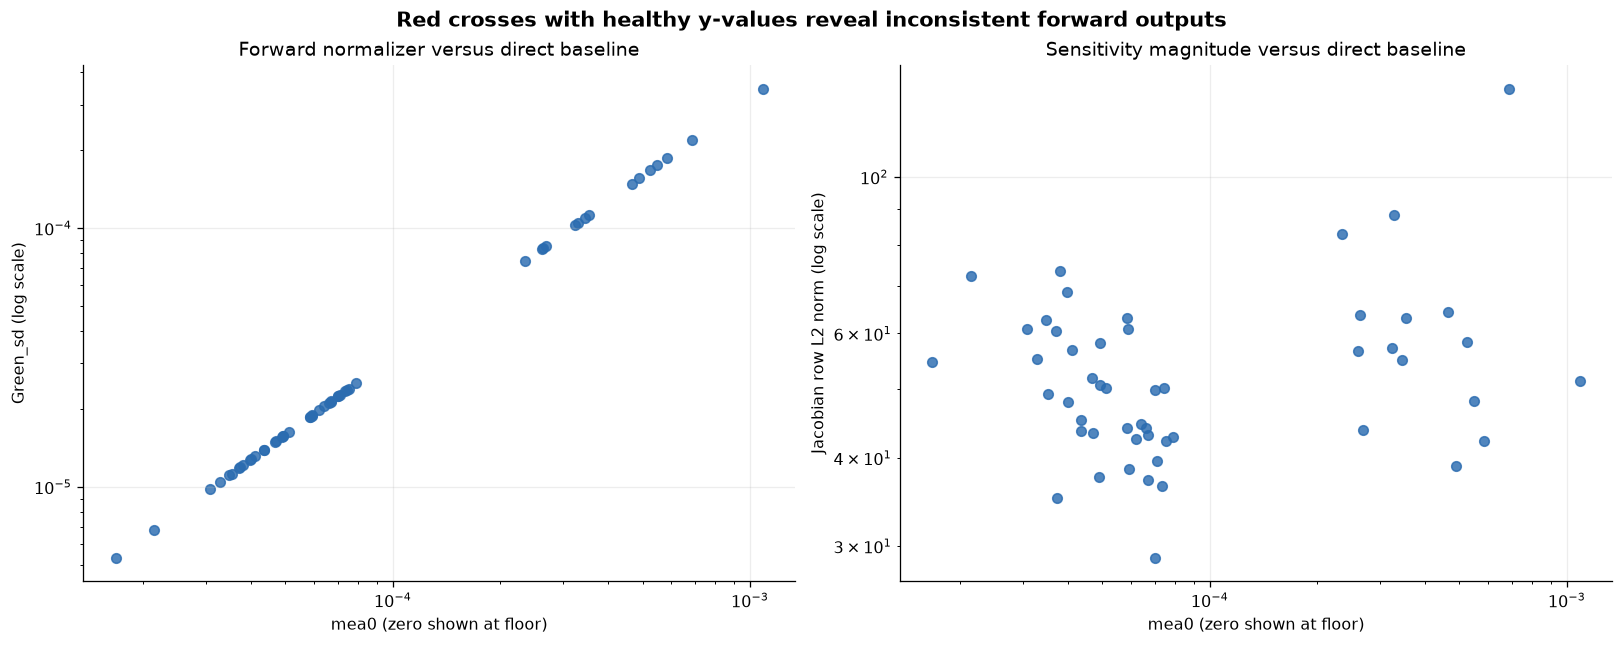

In [12]:
selected_normalizer = green_normalizer[selected_rows]
selected_jacobian_norm = jacobian_row_norm[selected_rows]

def scatter_against_baseline(axis, y_values, ylabel, title):
    y_values = np.asarray(y_values, dtype=float)
    positive_y = y_values[np.isfinite(y_values) & (y_values > 0)]
    y_floor = positive_y.min() / 10 if len(positive_y) else 1e-12
    plotted_y = np.where(np.isfinite(y_values) & (y_values > 0), y_values, y_floor)
    colors = np.where(selected_bad, "#d62728", "#2b6cb0")
    markers = ["x" if is_bad else "o" for is_bad in selected_bad]
    for x_value, y_value, color, marker in zip(
        plotted_baseline, plotted_y, colors, markers
    ):
        axis.scatter(x_value, y_value, color=color, marker=marker, alpha=0.82)
    for row, x_value, y_value in zip(
        selected_rows[selected_bad],
        plotted_baseline[selected_bad],
        plotted_y[selected_bad],
    ):
        axis.annotate(
            channel_label(row),
            (x_value, y_value),
            xytext=(3, 4),
            textcoords="offset points",
            fontsize=7,
            color="#7a0019",
        )
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set(title=title, xlabel="mea0 (zero shown at floor)", ylabel=ylabel)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), layout="constrained")
scatter_against_baseline(
    axes[0],
    selected_normalizer,
    "Green_sd (log scale)",
    "Forward normalizer versus direct baseline",
)
scatter_against_baseline(
    axes[1],
    selected_jacobian_norm,
    "Jacobian row L2 norm (log scale)",
    "Sensitivity magnitude versus direct baseline",
)
fig.suptitle(
    "Red crosses with healthy y-values reveal inconsistent forward outputs",
    fontsize=13,
    fontweight="bold",
)
plt.show()

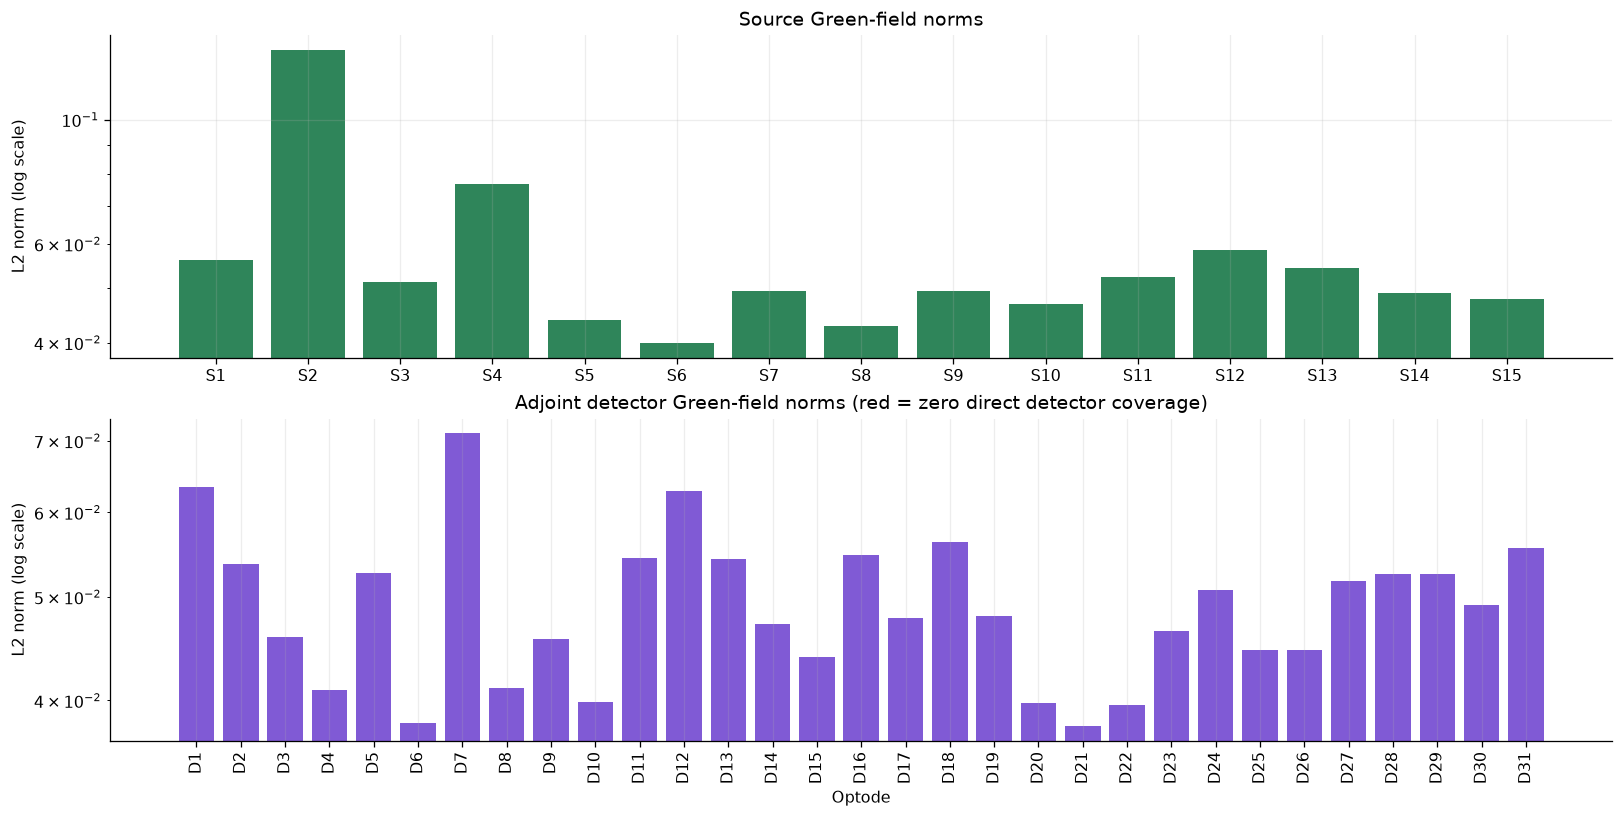

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), layout="constrained")

axes[0].bar(
    np.arange(source_count),
    source_green_norm,
    color=np.where(zero_coverage_sources, "#d62728", "#2f855a"),
)
axes[0].set_yscale("log")
axes[0].set(
    title="Source Green-field norms",
    ylabel="L2 norm (log scale)",
    xticks=np.arange(source_count),
    xticklabels=[f"S{i + 1}" for i in range(source_count)],
)

axes[1].bar(
    np.arange(detector_count),
    detector_green_norm,
    color=np.where(zero_coverage_detectors, "#d62728", "#805ad5"),
)
axes[1].set_yscale("log")
axes[1].set(
    title="Adjoint detector Green-field norms (red = zero direct detector coverage)",
    ylabel="L2 norm (log scale)",
    xlabel="Optode",
    xticks=np.arange(detector_count),
    xticklabels=[f"D{i + 1}" for i in range(detector_count)],
)
axes[1].tick_params(axis="x", rotation=90)
plt.show()

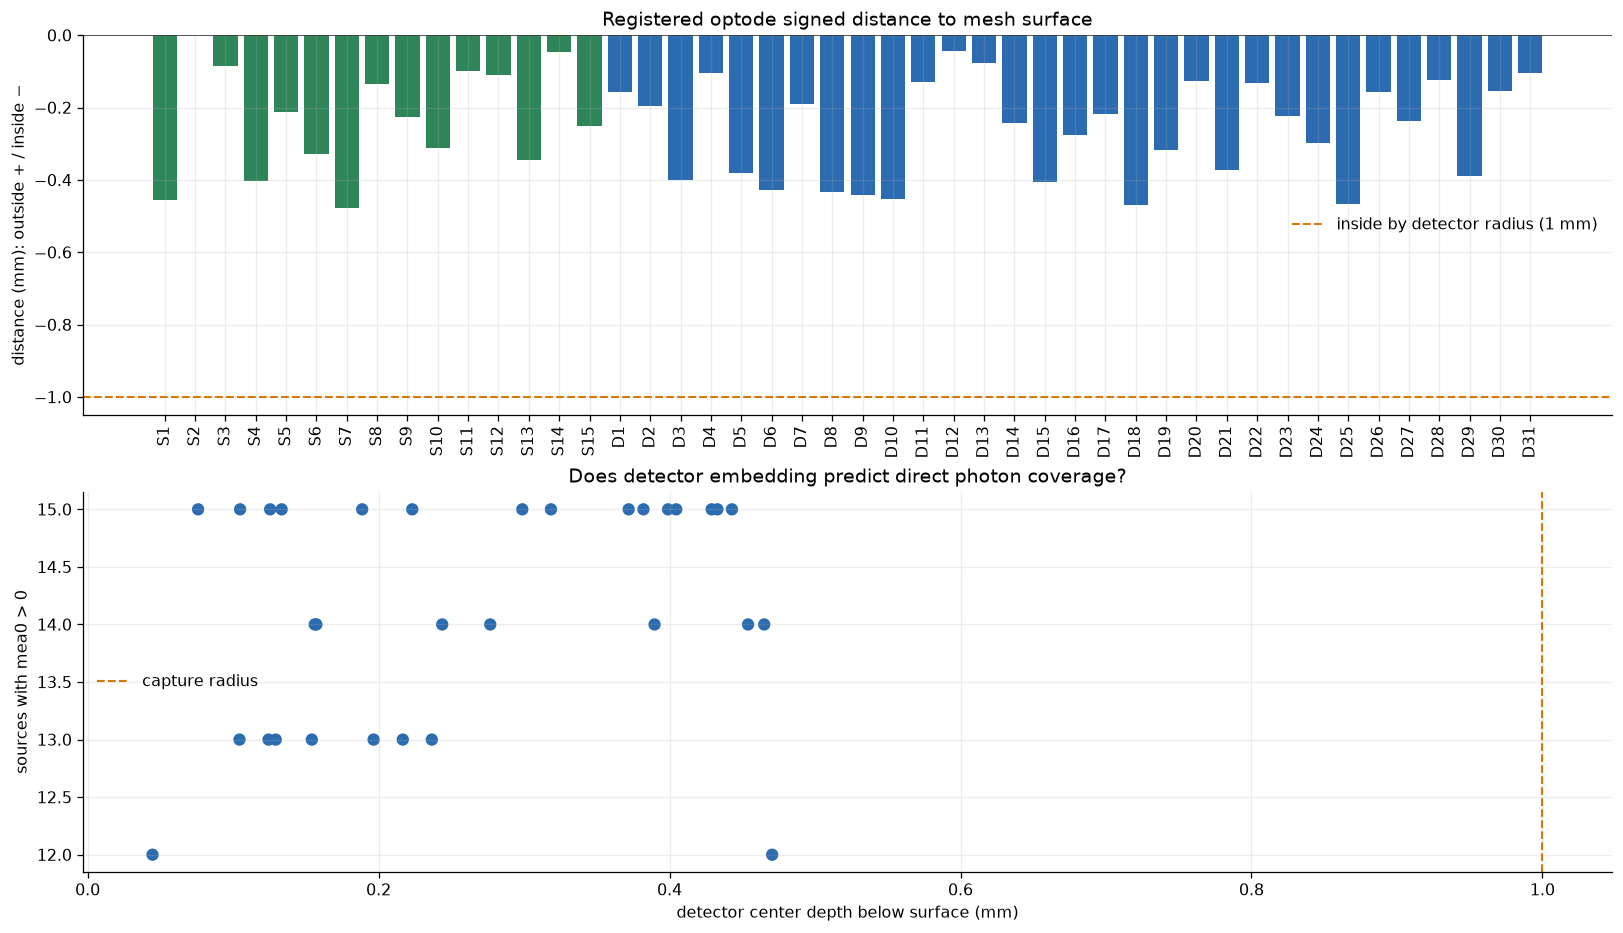

In [14]:
if surface_distances is None:
    display(Markdown("### Geometry plot skipped\n\nNo signed surface distances are available."))
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), layout="constrained")

    optode_labels = [f"S{i + 1}" for i in range(source_count)] + [
        f"D{i + 1}" for i in range(detector_count)
    ]
    optode_colors = ["#2f855a"] * source_count + [
        "#d62728" if failed else "#2b6cb0"
        for failed in zero_coverage_detectors
    ]
    optode_index = np.arange(source_count + detector_count)
    axes[0].bar(optode_index, surface_distances, color=optode_colors)
    axes[0].axhline(0, color="#333333", linewidth=1)
    if np.isfinite(detector_radius_mm):
        axes[0].axhline(
            -detector_radius_mm,
            color="#d97706",
            linestyle="--",
            linewidth=1.3,
            label=f"inside by detector radius ({detector_radius_mm:g} mm)",
        )
    axes[0].set(
        title="Registered optode signed distance to mesh surface",
        ylabel="distance (mm): outside + / inside −",
        xticks=optode_index,
        xticklabels=optode_labels,
    )
    axes[0].tick_params(axis="x", rotation=90)
    axes[0].legend(frameon=False)

    point_colors = np.where(zero_coverage_detectors, "#d62728", "#2b6cb0")
    axes[1].scatter(
        detector_depth,
        detector_coverage,
        c=point_colors,
        s=45,
    )
    if np.isfinite(detector_radius_mm):
        axes[1].axvline(
            detector_radius_mm,
            color="#d97706",
            linestyle="--",
            linewidth=1.3,
            label="capture radius",
        )
    for detector_index in np.flatnonzero(
        zero_coverage_detectors
        | (
            (detector_depth > detector_radius_mm)
            if np.isfinite(detector_radius_mm)
            else np.zeros(detector_count, dtype=bool)
        )
    ):
        axes[1].annotate(
            f"D{detector_index + 1}",
            (detector_depth[detector_index], detector_coverage[detector_index]),
            xytext=(3, 4),
            textcoords="offset points",
            fontsize=7,
            color="#7a0019" if zero_coverage_detectors[detector_index] else "#8a4b08",
        )
    axes[1].set(
        title="Does detector embedding predict direct photon coverage?",
        xlabel="detector center depth below surface (mm)",
        ylabel="sources with mea0 > 0",
    )
    axes[1].legend(frameon=False)
    plt.show()

In [17]:
bad_selected_rows = selected_rows[selected_bad_baseline[selected_rows]]
if len(bad_selected_rows) == 0:
    display(Markdown("## Bad selected channels\n\nNone."))
else:
    header = (
        "| Channel | Class | Separation (mm) | mea0 | Green_sd | "
        "J row norm | Detector coverage | Detector depth (mm) |"
    )
    lines = [
        "## Bad selected channels",
        "",
        header,
        "|:--|:--|--:|--:|--:|--:|--:|--:|",
    ]
    for row in bad_selected_rows:
        source_index, detector_index = divmod(int(row), detector_count)
        selected_position = int(np.flatnonzero(selected_rows == row)[0])
        channel_class = "short" if selected_is_short[selected_position] else "long"
        depth_text = (
            f"{detector_depth[detector_index]:.3f}"
            if detector_depth is not None
            else "n/a"
        )
        lines.append(
            f"| {channel_label(row)} | {channel_class} | "
            f"{source_detector_distances[source_index, detector_index]:.3f} | "
            f"{baseline[row]:.3e} | {green_normalizer[row]:.3e} | "
            f"{jacobian_row_norm[row]:.3e} | "
            f"{detector_coverage[detector_index]}/{source_count} | {depth_text} |"
        )
    display(Markdown("\n".join(lines)))

## Bad selected channels

None.

## How to read these diagnostics

Patterns worth stopping for:

- A **vertical magenta stripe** in the `mea0` heatmap means a detector received no direct photons from any source. A scattered bad cell instead points to a specific source-detector pairing.
- A **red cross at the plot floor** with a normal `Green_sd` or Jacobian norm means the sensitivity calculation looks numerically healthy while the direct forward measurement is unusable. This is especially dangerous because the archive can appear valid if only `J` is inspected.
- A detector with **zero direct coverage but nonzero adjoint Green norm** distinguishes a capture/geometry problem from a failed detector-as-source MMC run.
- A cluster of failed detectors whose centers are **deeper than the capture radius** implicates probe embedding or the detector radius used by MMC.
- Large isolated log-scale outliers, non-finite rows, probe/Jacobian pairing mismatches, or a different failure pattern between wavelengths also require investigation.

Recommended upstream gates for mmcnirs:

1. During probe registration, report signed optode depth and explicitly compare detector depth with the capture radius used by MMC.
2. After every source MMC run, require a positive detected-photon weight for each selected detector paired with that source.
3. Before saving, require finite positive selected `mea0`, finite positive `Green_sd`, finite nonzero selected Jacobian rows, and exact probe/Jacobian selection agreement.
4. Save the detector radius and relevant simulation settings as named metadata rather than relying on a position-array convention.